In [52]:
import torch
import matplotlib.pyplot as plt

### Exercise 1 

Create a neural network with 5 layers that take a real number to
another number, and plot it on $[-3,3]$

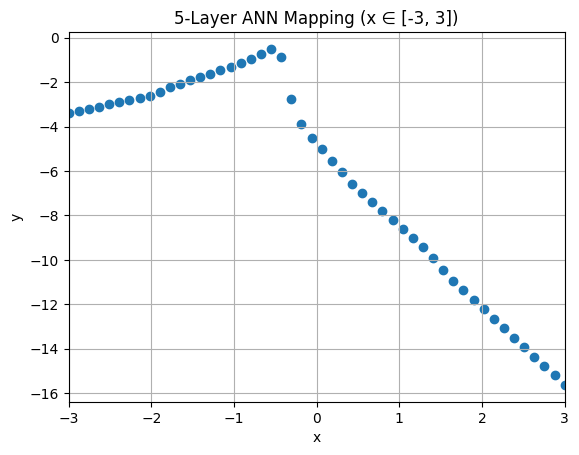

In [53]:
def relu(x):
    zero_tensor = torch.zeros_like(x)
    return torch.max(zero_tensor, x)

class ANN:
    def __init__(self, input_dim, output_dim):
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.linear = torch.randn(self.input_dim, self.output_dim)
        self.bias = torch.randn(self.output_dim)

    def map(self, x):
        return x @ self.linear + self.bias
    

def FiveLayerANN(x):
    L1 = ANN(1, 10)
    L2 = ANN(10, 15)
    L3 = ANN(15, 10)
    L4 = ANN(10, 5)
    L5 = ANN(5, 1)

    a = L1.map(x)
    a_act = relu(a)

    b = L2.map(a_act)
    b_act = relu(b)

    c = L3.map(b_act)
    c_act = relu(c)

    d = L4.map(c_act)
    d_act = relu(d)

    out = L5.map(d_act)
    
    return out


x = torch.linspace(-3, 3, 50).unsqueeze(1)
y = FiveLayerANN(x)

plt.scatter(x.numpy(), y.numpy())
plt.title("5-Layer ANN Mapping (x ∈ [-3, 3])")
plt.xlim(-3, 3)
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()


### Exercise 2 
Create a neural network with 3 layers from $R$ to $R$, call it $f$.

1. Find $f(0)$
2. Find $f'(0)$
3. Plot $f$ on $[−1, 2]$
4. Approximate $\int_{-1}^{2} f(x) \,dx$

The neural network we just created is static and we can’t really improve it.

In [ ]:
def relu(x):
    zero_tensor = torch.zeros_like(x)
    return torch.max(zero_tensor, x)

class ANN:
    def __init__(self, input_dim, output_dim):
        self.linear = torch.randn(input_dim, output_dim, requires_grad=True)
        self.bias = torch.randn(output_dim, requires_grad=True)

    def map(self, x):
        return x @ self.linear + self.bias

def ThreeLayerANN(x, layers):
    L1, L2, L3 = layers

    a = relu(L1.map(x))
    b = relu(L2.map(a))
    out = relu(L3.map(b))
    
    return out

layers = [
    ANN(1, 10),
    ANN(10, 15),
    ANN(15, 1)
]

x = torch.tensor([0.0], requires_grad=True)
y = ThreeLayerANN(x, layers)
print(f"If x = 0 => y = {y}")

If x = 0 => y = tensor([0.], grad_fn=<MaximumBackward0>)


In [55]:
y.sum().backward()
print("Gradient dy/dx at x=0:", x.grad)

Gradient dy/dx at x=0: tensor([0.])


### Exercise 3 

Create a neural network with 4 layers that takes a real number to
another number, and plot it on [−5, 5].

In [ ]:
import torch.nn as nn


class FourLayerANN(nn.Module):
    def __init__(self, input_dim, hidden1_dim, hidden2_dim, hidden3_dim, output_dim):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, hidden1_dim)
        self.layer2 = nn.Linear(hidden1_dim, hidden2_dim)
        self.layer3 = nn.Linear(hidden2_dim, hidden3_dim)
        self.layer4 = nn.Linear(hidden3_dim, output_dim)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)

        x = self.layer2(x)
        x = self.relu(x)

        x = self.layer3(x)
        x = self.relu(x)

        out = self.layer4(x)

        return out
    
model = FourLayerANN(1, 5, 10, 5, 1)
print(model)


FourLayerANN(
  (layer1): Linear(in_features=1, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=5, bias=True)
  (layer4): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)


In [62]:
x = torch.tensor([0.5])
y = model.forward(x)
print(y)

tensor([0.0204], grad_fn=<ViewBackward0>)


In [68]:
class FourLayerANN(nn.Module):
    def __init__(self, input_dim, hidden1_dim, hidden2_dim, hidden3_dim, output_dim):
        super().__init__()

        self.layer1 = nn.Linear(input_dim, hidden1_dim)
        self.layer2 = nn.Linear(hidden1_dim, hidden2_dim)
        self.layer3 = nn.Linear(hidden2_dim, hidden3_dim)
        self.layer4 = nn.Linear(hidden3_dim, output_dim)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)

        x = self.layer2(x)
        x = self.relu(x)

        x = self.layer3(x)
        x = self.relu(x)

        out = self.layer4(x)

        return out

In [70]:
model = FourLayerANN(2, 5, 10, 5, 1)
print(model)

FourLayerANN(
  (layer1): Linear(in_features=2, out_features=5, bias=True)
  (layer2): Linear(in_features=5, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=5, bias=True)
  (layer4): Linear(in_features=5, out_features=1, bias=True)
  (relu): ReLU()
)


In [72]:
x = torch.tensor([[1.0, 1.0]])
y = model.forward(x)